In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
def predict(weight, bias, point):
    sign = np.sign(weight @ point + bias)
    return 1 if sign >= 0 else -1

def classify(x_train, y_train, weight, bias):
    pred = np.array([predict(weight, bias, pt) for pt in x_train])
    misclassified_pts = pred != y_train
    return x_train[misclassified_pts], y_train[misclassified_pts]

def plot(misclassified_per_epoch, x_train, y_train, x_val, y_val, weight, bias, dataset_name):
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Perceptron Results: {dataset_name}', fontsize=16)

    epochs = list(misclassified_per_epoch.keys())
    errors = list(misclassified_per_epoch.values())
    axs[0].plot(epochs, errors, marker='o', color='red')
    axs[0].set_title('Misclassifications per Epoch')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Number of Misclassified Samples')
    axs[0].grid(True)

    def plot_boundary(ax, x_data, y_data, title):
        ax.scatter(x_data[:, 0], x_data[:, 1], c=y_data, cmap='bwr', edgecolors='k', alpha=0.7)
        
        if weight[1] != 0:
            x_min, x_max = x_data[:, 0].min() - 1, x_data[:, 0].max() + 1
            x_vals = np.array([x_min, x_max])
            y_vals = -(weight[0] * x_vals + bias) / weight[1]
            ax.plot(x_vals, y_vals, 'k--', lw=2, label='Decision Boundary')
            ax.legend()
        
        ax.set_title(title)
        ax.set_xlabel('X1')
        ax.set_ylabel('X2')

    plot_boundary(axs[1], x_train, y_train, 'Training Data')
    plot_boundary(axs[2], x_val, y_val, 'Validation Data')

    plt.tight_layout()
    plt.show()

def train_perceptron(x_train, y_train, x_val, y_val, dataset_name):

    #initialise with zero weights
    weight = np.zeros(2)
    bias = 0
    eta = 0.01

    misclassified_per_epoch = {}
    #for 300 epochs
    for i in range(300):
        misclassified, label = classify(x_train, y_train, weight, bias)
        #get indices of all misclassified samples 
        total = len(misclassified)
        misclassified_per_epoch[i+1] = total
        #get total number of misclassified samples
        
        if (total > 0):
            #pick random misclassified point for stochastic gradient descent
            index = np.random.choice(len(misclassified))
            xi = misclassified[index]
            yi = label[index]

            weight = weight + eta*yi*xi
            bias = bias + eta*yi
        else:
            print(f"Convergence Epoch Observed at {i}th Epoch")
            break

    misclassified, label = classify(x_val, y_val, weight, bias)
    print(f"Model Accuracy on Test Set = {(1-len(misclassified)/len(x_val))*100}%")
    plot(misclassified_per_epoch, x_train, y_train, x_val, y_val, weight, bias, dataset_name)
    return (weight, bias)

import numpy as np

def train_test_split(X, y, test_size=0.3, random_seed=None):
    if random_seed is not None:
        np.random.seed(random_seed)
        
    num_samples = X.shape[0]
    indices = np.arange(num_samples)
    np.random.shuffle(indices)
    split_index = int(num_samples * (1 - test_size))
    
    train_indices = indices[:split_index]
    test_indices = indices[split_index:]
    
    X_train = X[train_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]
    
    return X_train, X_test, y_train, y_test

Dataset A
Convergence Epoch Observed at 1th Epoch
Model Accuracy on Test Set = 100.0%


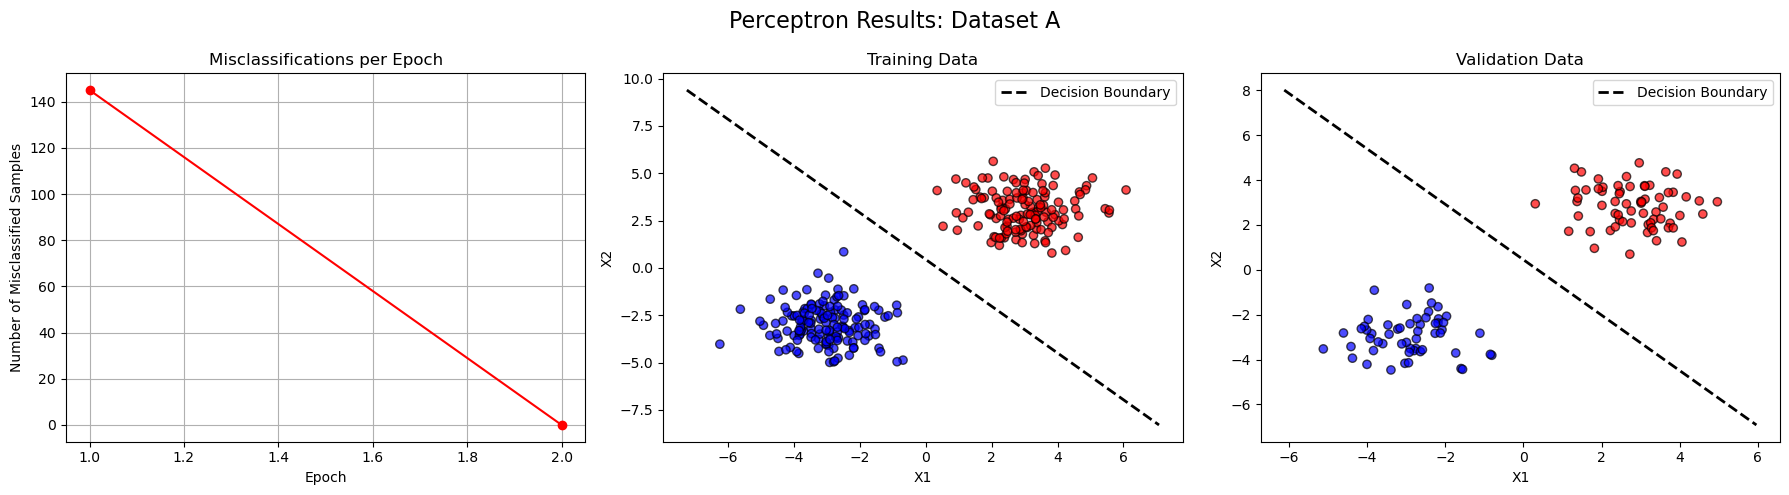

Dataset B
Convergence Epoch Observed at 13th Epoch
Model Accuracy on Test Set = 99.16666666666667%


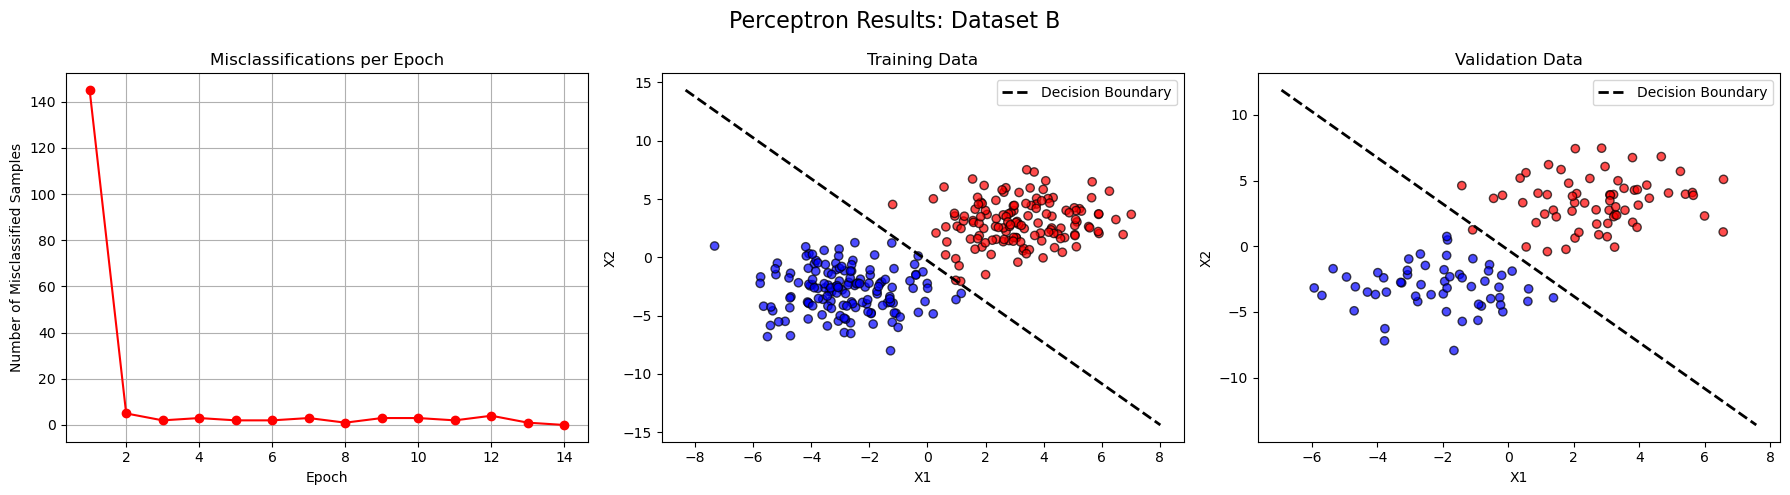

In [27]:
#dataset A
np.random.seed(42)
mean_neg = [-3, -3]
mean_pos = [3, 3]
cov_A = [[1, 0], [0, 1]]

X_neg_A = np.random.multivariate_normal(mean_neg, cov_A, 200)
X_pos_A = np.random.multivariate_normal(mean_pos, cov_A, 200)
y_neg = -np.ones(200)
y_pos = np.ones(200)

X_A = np.vstack((X_neg_A, X_pos_A))
y_A = np.hstack((y_neg, y_pos))

#dataset B with cov = 3I
cov_B = [[3, 0], [0, 3]]
X_neg_B = np.random.multivariate_normal(mean_neg, cov_B, 200)
X_pos_B = np.random.multivariate_normal(mean_pos, cov_B, 200)

X_B = np.vstack((X_neg_B, X_pos_B))
y_B = np.hstack((y_neg, y_pos))

#70-30 split for train and val
X_train_A, X_val_A, y_train_A, y_val_A = train_test_split(X_A, y_A, test_size=0.3, random_seed=42)
X_train_B, X_val_B, y_train_B, y_val_B = train_test_split(X_B, y_B, test_size=0.3, random_seed=42)

#training
print("Dataset A")
w_A, b_A = train_perceptron(X_train_A, y_train_A, X_val_A, y_val_A, "Dataset A")

print("Dataset B")
w_B, b_B = train_perceptron(X_train_B, y_train_B, X_val_B, y_val_B, "Dataset B")